# 1、读取 abaqus inp 文件，展示节点信息图

### 该版本停用，2023年12月29日，09点38分。继续使用v2版本。优化内容：1、封装相关函数到.py文件。 2、重新整理了程序框架

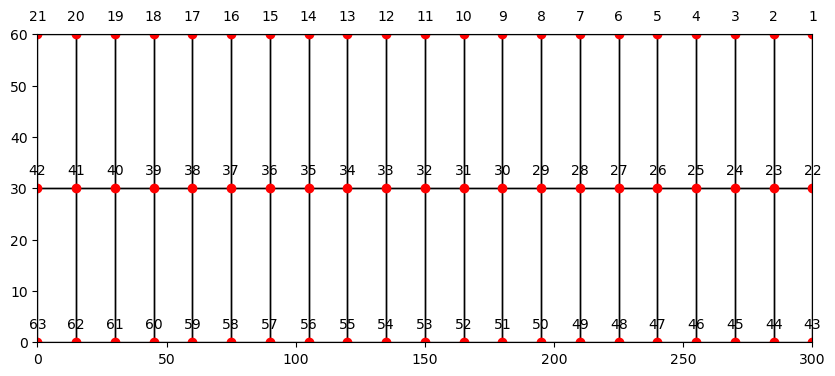

In [1]:
# Show nodes
import DM_ShowNodes as DMshow
file_path = "E:\phd\Code\DM-FEM2D\Fem_inp\Job-1_largemesh.inp"
label_interval = 1
node = DMshow.plot_fea_model(file_path, label_interval)
#node_ids = [41, 39, 37, 35, 33, 31, 29, 27, 25, 23]

# 2、读取abaqus到处的有限元质量矩阵和刚度矩阵,并执行缩减自由度操作

In [1]:
# 读取矩阵，并执行缩减自由度操作
import DM_Reading as dm_r
file_m = 'E:\phd\Code\DM-FEM2D\StructureData\Job-1_largemesh_ConsistentMass_MASS1.mtx'
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\Job-1_largemesh_STIF1.mtx'
M = dm_r.get_stiffness_matrix(file_m)
k = dm_r.get_stiffness_matrix(file_k)
import numpy as np

def reduce_dofs(matrix, num_nodes, dof_to_remove):
    """
    Reduce the degrees of freedom (DOFs) of a matrix by removing specified DOFs for each node.

    :param matrix: The original square matrix representing the system.
    :param num_nodes: The number of nodes in the system.
    :param dof_to_remove: A list of DOFs to remove for each node.
    :return: The reduced matrix.
    """
    # Total number of DOFs per node (assuming square matrix)
    total_dofs = matrix.shape[0]
    dofs_per_node = total_dofs // num_nodes

    # Generate the indices of DOFs to keep
    keep_dofs = [i for node in range(num_nodes) 
                 for i in range(node*dofs_per_node, (node+1)*dofs_per_node) 
                 if (i - node*dofs_per_node) not in dof_to_remove]

    # Reduce the matrix
    reduced_matrix = matrix[np.ix_(keep_dofs, keep_dofs)]
    return reduced_matrix

# matrix = np.random.rand(378, 378)  
M_consistant= reduce_dofs(M, 63, [5])
k = reduce_dofs(k, 63, [5])

In [2]:
# 将协调质量转化为集中质量
def lump_mass_matrix(consistant_mass_matrix):
    """
    将一致质量矩阵转换为集中质量矩阵。

    参数:
    consistant_mass_matrix (np.array): 一致质量矩阵。

    返回:
    np.array: 集中质量矩阵。
    """
    # 将每行元素加到对角线上
    np.fill_diagonal(consistant_mass_matrix, np.diagonal(consistant_mass_matrix) + consistant_mass_matrix.sum(axis=1))

    # 然后将非对角线元素置0
    lumped_mass_matrix = np.diag(np.diagonal(consistant_mass_matrix))

    return lumped_mass_matrix

M_lumped = lump_mass_matrix(M_consistant)
beta = 1
M = beta * M_lumped + (1 - beta) * M_consistant

## 2.1 check 模态

[  4.65677382   4.95687949  19.07649948  19.17449304  27.60060938
  45.19371332  52.3894532   85.45276166 117.82131466 143.83195413
 213.63957509 216.45711368 225.51525746 237.37878725]


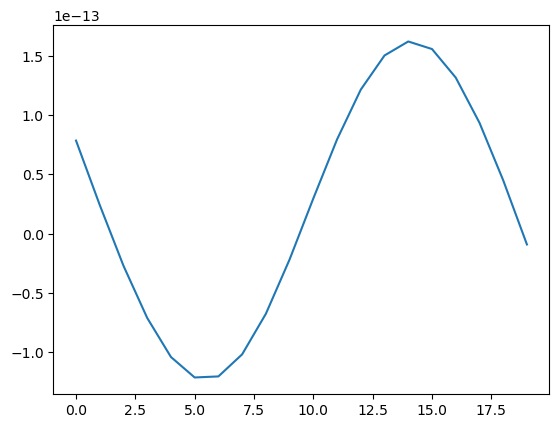

In [3]:
#该部分只用于检查，可不运行
import numpy as np
from scipy.linalg import eigh
eigenvalues, eigenvectors = eigh(k, M)
print(eigenvalues[6:20])
mid = eigenvectors[22*5-5:42*5-5,:]
import matplotlib.pyplot as plt
plt.plot(mid[2::5,6])

# 3、使用python复现SEREP函数方法

In [4]:
# 为了快速读取SlaveDofs而创建的函数
import numpy as np
def create_dof_matrix(num_nodes, nodes_to_remove):
    """
    Create a DOF matrix for a system with a specified number of nodes,
    each having 6 DOFs, and remove the DOFs corresponding to specified nodes.

    Parameters:
    num_nodes (int): Number of nodes in the system.
    nodes_to_remove (list): List of node IDs whose DOFs are to be removed.

    Returns: 
    numpy.ndarray: A matrix with remaining DOFs.
    """
    # Each node has 6 DOFs
    total_dofs = num_nodes * 5

    # Initialize an array to represent all DOFs
    dof_array = np.arange(total_dofs)

    # Adjust the nodes_to_remove to zero-based indexing
    nodes_to_remove_zero_based = [node - 1 for node in nodes_to_remove]
    # Calculate the DOF indices for the nodes to remove
    dofs_to_remove = []
    for node_id in nodes_to_remove_zero_based:
        start_dof = node_id * 5
        dofs_to_remove.extend(range(start_dof, start_dof + 5))

    
    # Remove the specified DOFs
    remaining_dofs = np.delete(dof_array, dofs_to_remove)

    return np.array(dofs_to_remove),np.array(remaining_dofs)

# Example usage
num_nodes = 63
master = [41, 39, 37, 35, 33, 31, 29, 27, 25, 23]
MasterDofs,SlaveDofs = create_dof_matrix(num_nodes, master)
SlaveDofs.shape

(265,)

In [5]:
# 执行缩减矩阵
import numpy as np
from scipy.linalg import eigh

def SEREP(K, M, SlaveDofs):
    # Sort the SlaveDofs
    SlaveDofs = np.sort(SlaveDofs)
    #矩阵重组
    # Create index array for remaining DOFs
    index = np.setdiff1d(np.arange(K.shape[0]), SlaveDofs)
    M1 = M[index[:, np.newaxis], index]
    M2 = M[index[:, np.newaxis], SlaveDofs]
    M3 = M[SlaveDofs[:, np.newaxis], index]
    M4 = M[SlaveDofs[:, np.newaxis], SlaveDofs]
    k1 = K[index[:, np.newaxis], index]
    k2 = K[index[:, np.newaxis], SlaveDofs]
    k3 = K[SlaveDofs[:, np.newaxis], index]
    k4 = K[SlaveDofs[:, np.newaxis], SlaveDofs]
    M = np.vstack([np.hstack([M1, M2]), np.hstack([M3, M4])])
    K = np.vstack([np.hstack([k1, k2]), np.hstack([k3, k4])])
    # Solve the eigenvalue problem
    eigenvalues, eigenvectors = eigh(K, M)
    # Define transformation matrices
    T = eigenvectors[:,0:50] @ np.linalg.inv(eigenvectors[0:50,0:50])
    # Calculate the reduced mass and stiffness matrices
    MR = T.T @ M @ T
    KR = T.T @ K @ T
    
    return MR,KR,T
    
# Example usage:
MR,KR,T = SEREP(k, M, SlaveDofs)


# 4、读取水动力数据，构建运动方程，求解位移响应

In [6]:
#import packages
import time
import numpy as np
import capytaine as cpt
import scipy
from capytaine.io.mesh_writers import write_STL
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
import vtk
import logging
import xarray as xr
from capytaine.io.xarray import merge_complex_values
from capytaine.post_pro import rao
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s: %(message)s')

In [7]:
dataset = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM10_120_direction0.nc"))

In [8]:
# Extract matrices and force from the dataset
added_mass = dataset['added_mass'][0].values
radiation_damping = dataset['radiation_damping'][0].values
inertia_matrix = dataset['inertia_matrix'].values
hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
F_w = dataset['Froude_Krylov_force'][0].values + dataset['diffraction_force'][0].values
# REDUCE THE MATRICES
added_mass = reduce_dofs(added_mass,10,[5])
radiation_damping = reduce_dofs(radiation_damping,10,[5])
hydrostatic_stiffness = reduce_dofs(hydrostatic_stiffness,10,[5])
inertia_matrix = reduce_dofs(inertia_matrix,10,[5])
# REDUCE THE FORCE
def reduce_force_matrix_dofs(force_matrix, num_nodes, dof_to_remove):
    """
    Reduce the degrees of freedom (DOFs) of a force matrix by removing the specified DOF for each node.

    :param force_matrix: The original force matrix (1D array).
    :param num_nodes: The number of nodes.
    :param dof_to_remove: The DOF to remove for each node (0-indexed).
    :return: The reduced force matrix.
    """
    dofs_per_node = force_matrix.size // num_nodes
    keep_dofs = [i for node in range(num_nodes) for i in range(node*dofs_per_node, node*dofs_per_node + dofs_per_node) if i % dofs_per_node != dof_to_remove]
    # print(keep_dofs)
    # Flatten the force_matrix if it's 2D, then select the DOFs to keep
    return force_matrix.flatten()[keep_dofs]

F_w = reduce_force_matrix_dofs(F_w, 10, 5).reshape(1,50)

# Generate the system matrices
mass = added_mass + MR
damping = radiation_damping
stiffness = hydrostatic_stiffness + KR

import DM_Assemble as DM_A
omega = 0.648  # Here we use 1.0 as an example, in actual applications you should use your real data
X = DM_A.solve_frequency_domain(mass, damping, stiffness, F_w, omega)  # Solve in frequency domain


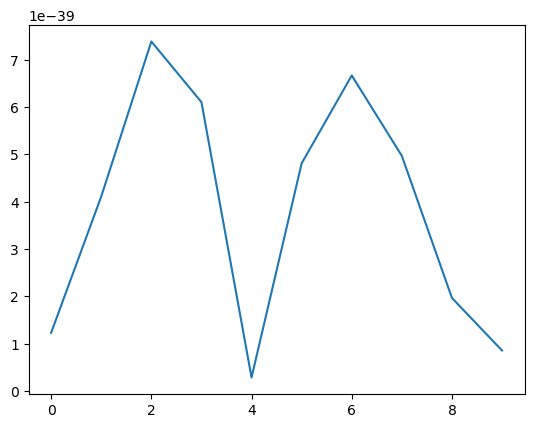

In [9]:
import matplotlib.pyplot as plt
heave = abs(X[2::5])
plt.plot(heave)

In [10]:
X_N = T @ X

In [11]:
# 恢复原始的节点顺序
def reorder_displacement_matrix(displacement_matrix, master_dofs, slave_dofs):
    """
    Reorder a displacement matrix from [master_dofs, slave_dofs] order to natural order (1, 2, 3, ...).

    :param displacement_matrix: The original displacement matrix (2D array).
    :param master_dofs: List or array of master degrees of freedom in current order.
    :param slave_dofs: List or array of slave degrees of freedom in current order.
    :return: The reordered displacement matrix.
    """
    # 创建从当前顺序到自然顺序的映射
    total_dofs = len(master_dofs) + len(slave_dofs)
    current_order = np.concatenate([master_dofs[::-1], slave_dofs])
    natural_order = np.empty(total_dofs, dtype=int)
    natural_order[current_order] = np.arange(total_dofs)

    # 根据自然顺序重排位移矩阵
    reordered_matrix = displacement_matrix[natural_order, :]
    return reordered_matrix

# Example usage:
reordered_matrix = reorder_displacement_matrix(X_N, MasterDofs, SlaveDofs)
# The reordered_matrix is now reordered according to the specified node order



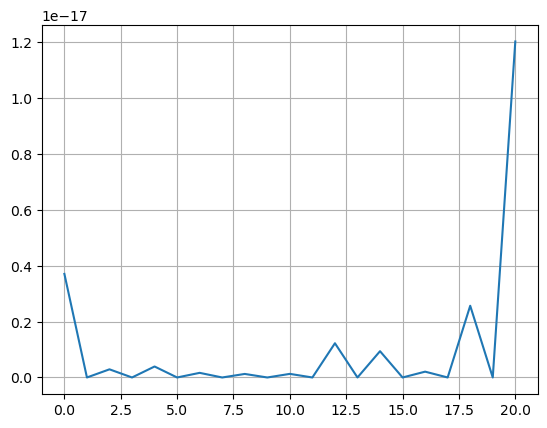

In [12]:
import matplotlib.pyplot as plt
mid = reordered_matrix[22*5-5:43*5-5,:]
heave = abs(mid[2::5])
plt.plot(heave)
plt.grid(True)

In [14]:
F = k@reordered_matrix

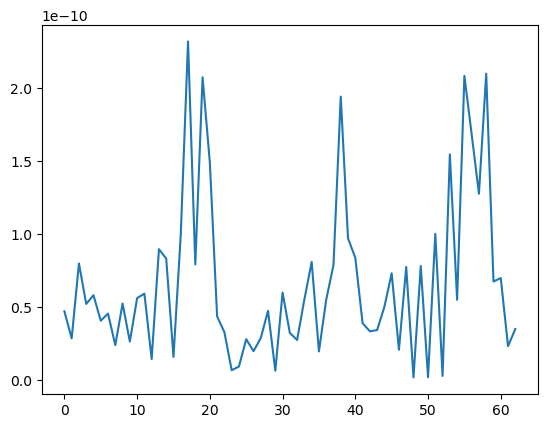

In [15]:
F_mid = F[22*5-5:43*5-5,:]
plt.plot(abs(F[4::5]))

## 程序验证

Text(0, 0.5, 'Heave RAO ($m$/$m$)')

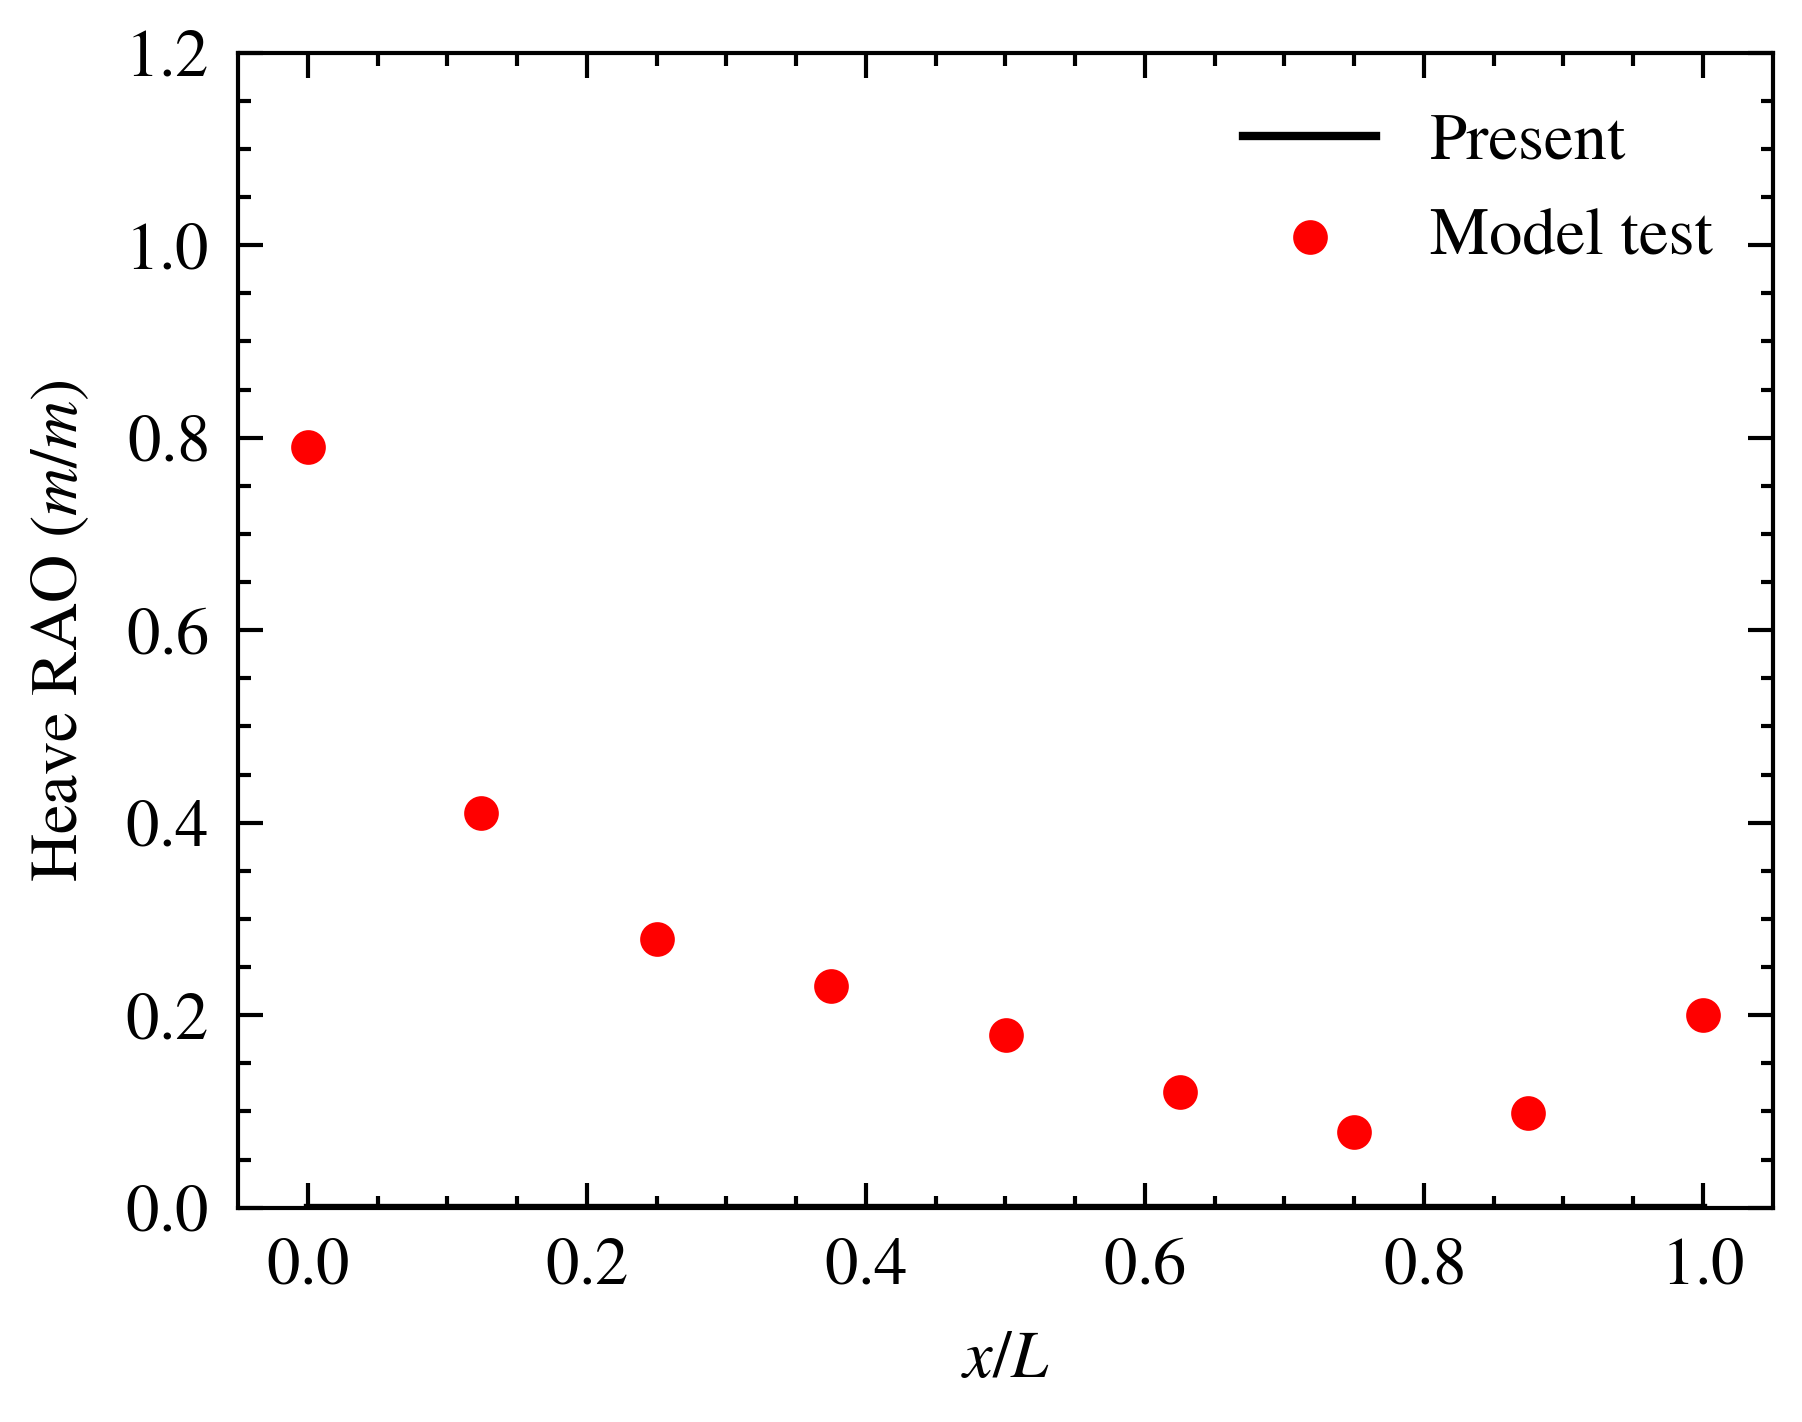

In [16]:
# 与实验结果进行对比、绘图
from DM_Verify import process_exp_data
x, y = process_exp_data("E:\phd\Code\DM-FEM2D\data\Experiment_300_60\exp_120.txt")
y = np.array(y)

# 绘图
import scienceplots
x1 = np.linspace(0,1,21)
plt.style.use(['science','no-latex','ieee'])
plt.plot(x1,abs(mid[2::5]), label="Present")
plt.scatter(x,y,color = 'red',label="Model test",s=10)
plt.legend() 
plt.ylim(0,1.2) # 调整y轴坐标
plt.xlabel(r'$x/L$',)
plt.ylabel(r'Heave RAO ($m$/$m$)')